In [6]:
colors = ['#576fa0', '#b57979', '#e3b87f', '#90c266']
import MDAnalysis as mda
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist


<ipython-input-4-42b584dddebc>:58: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


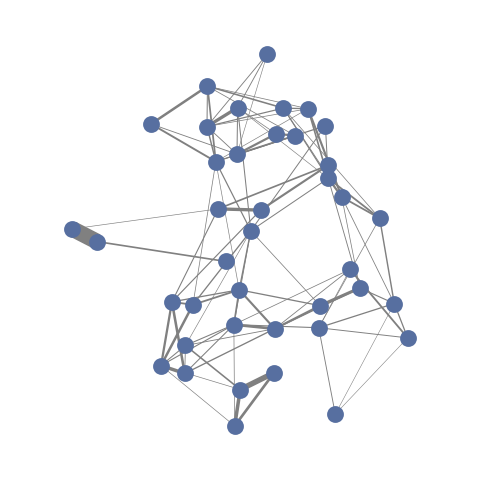

In [4]:
# Load trajectory
u = mda.Universe("./full_cahs12-3/protein_shifted.pdb", "./full_cahs12-3/protein.xtc")
# Select each protein — assuming each protein is in its own segment
proteins = [seg.atoms for seg in u.segments]

# Distance cutoff in nm
cutoff = 0.4  # 0.4 nm = 4 Å

# Go to last frame
u.trajectory[-1]

# Create an undirected graph
G = nx.Graph()

# Add nodes
for i in range(len(proteins)):
    G.add_node(i)

# Add edges based on contact, and set edge weight as 1 / COM distance
for i in range(len(proteins)):
    for j in range(i + 1, len(proteins)):
        pos_i = proteins[i].positions
        pos_j = proteins[j].positions
        
        # Check if any pair of atoms are within cutoff distance
        dist_matrix = cdist(pos_i, pos_j)
        if np.any(dist_matrix < cutoff * 10):  # cutoff in Å
            # Compute COM distance
            com_i = proteins[i].center_of_mass()
            com_j = proteins[j].center_of_mass()
            com_dist = np.linalg.norm(com_i - com_j)
            weight = 1.0 / com_dist if com_dist != 0 else 0.0
            G.add_edge(i, j, weight=weight)

# For plotting, use 2D COM as node positions

#positions = {i: proteins[i].center_of_mass()[:2] for i in range(len(proteins))}
weights = [G[u][v]['weight'] * 50 for u, v in G.edges()]  # scaled for better visibility
positions = nx.spring_layout(G, seed=100)


plt.figure(figsize=(3, 3), dpi=150)
nx.draw(
    G, positions,
    with_labels=False,
    node_color='#576fa0',
    edge_color='gray',
    width=weights,
    node_size=50
)
plt.axis("equal")
plt.tight_layout()
plt.savefig('net-full.pdf', format='pdf', dpi=400, transparent=True, bbox_inches='tight')

plt.show()

<ipython-input-5-edf65a3541f9>:57: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


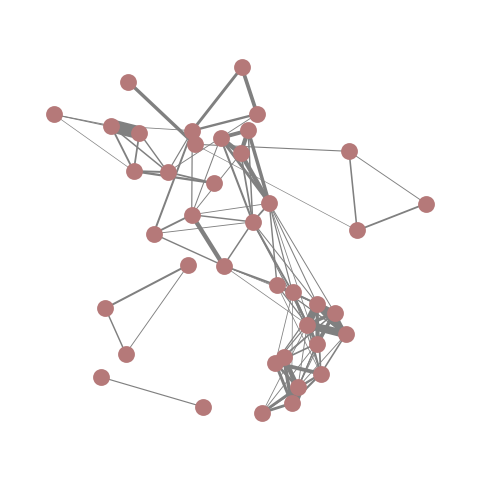

In [5]:
import MDAnalysis as mda
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist

# Load trajectory
u = mda.Universe("./delta_C-2/protein_shifted.pdb", "./delta_C-2/protein.xtc")

# Select each protein — assuming each protein is in its own segment
proteins = [seg.atoms for seg in u.segments]

# Distance cutoff in nm
cutoff = 0.4  # 0.4 nm = 4 Å

# Go to last frame
u.trajectory[-1]

# Create an undirected graph
G = nx.Graph()

# Add nodes
for i in range(len(proteins)):
    G.add_node(i)

# Add edges based on contact, and set edge weight as 1 / COM distance
for i in range(len(proteins)):
    for j in range(i + 1, len(proteins)):
        pos_i = proteins[i].positions
        pos_j = proteins[j].positions
        
        # Check if any pair of atoms are within cutoff distance
        dist_matrix = cdist(pos_i, pos_j)
        if np.any(dist_matrix < cutoff * 10):  # cutoff in Å
            # Compute COM distance
            com_i = proteins[i].center_of_mass()
            com_j = proteins[j].center_of_mass()
            com_dist = np.linalg.norm(com_i - com_j)
            weight = 1.0 / com_dist if com_dist != 0 else 0.0
            G.add_edge(i, j, weight=weight)

# For plotting, use 2D COM as node positions
positions = nx.spring_layout(G, seed=100)
weights = [G[u][v]['weight'] * 50 for u, v in G.edges()]  # scaled for better visibility

# Plotting
plt.figure(figsize=(3, 3), dpi=150)
nx.draw(
    G, positions,
    with_labels=False,
    node_color='#b57979',
    edge_color='gray',
    width=weights,
    node_size=50
)
plt.axis("equal")
plt.tight_layout()
plt.savefig('net-dC.pdf',format='pdf', dpi=400, transparent=True, bbox_inches='tight')
plt.show()


<ipython-input-6-b3ad4d99ef6b>:57: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


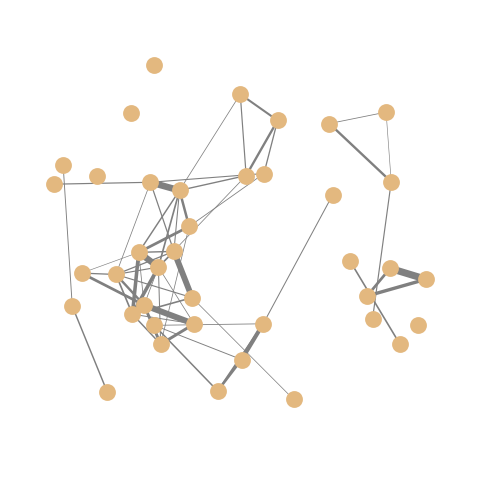

In [6]:
import MDAnalysis as mda
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist

# Load trajectory
u = mda.Universe("./delta_N-3/protein_shifted.pdb", "./delta_N-3/protein.xtc")

# Select each protein — assuming each protein is in its own segment
proteins = [seg.atoms for seg in u.segments]

# Distance cutoff in nm
cutoff = 0.4  # 0.4 nm = 4 Å

# Go to last frame
u.trajectory[-1]

# Create an undirected graph
G = nx.Graph()

# Add nodes
for i in range(len(proteins)):
    G.add_node(i)

# Add edges based on contact, and set edge weight as 1 / COM distance
for i in range(len(proteins)):
    for j in range(i + 1, len(proteins)):
        pos_i = proteins[i].positions
        pos_j = proteins[j].positions
        
        # Check if any pair of atoms are within cutoff distance
        dist_matrix = cdist(pos_i, pos_j)
        if np.any(dist_matrix < cutoff * 10):  # cutoff in Å
            # Compute COM distance
            com_i = proteins[i].center_of_mass()
            com_j = proteins[j].center_of_mass()
            com_dist = np.linalg.norm(com_i - com_j)
            weight = 1.0 / com_dist if com_dist != 0 else 0.0
            G.add_edge(i, j, weight=weight)

# For plotting, use 2D COM as node positions
weights = [G[u][v]['weight'] * 50 for u, v in G.edges()]  # scaled for better visibility
positions = nx.spring_layout(G, seed=42)

# Plotting
plt.figure(figsize=(3, 3), dpi=150)
nx.draw(
    G, positions,
    with_labels=False,
    node_color='#e3b87f',
    edge_color='gray',
    width=weights,
    node_size=50
)
plt.axis("equal")
plt.tight_layout()
plt.savefig('net-dN.pdf',format='pdf', dpi=400, transparent=True, bbox_inches='tight')
plt.show()


<ipython-input-2-9bcdf9cb4c86>:58: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


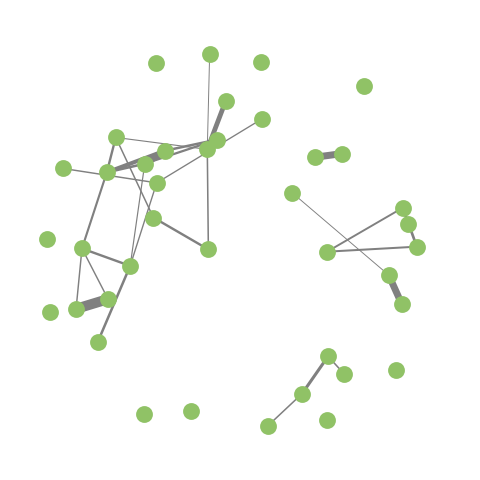

In [2]:
import MDAnalysis as mda
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist

# Load trajectory
u = mda.Universe("./linker-3/protein_shifted.pdb", "./linker-3/protein.xtc")
# Select each protein — assuming each protein is in its own segment
proteins = [seg.atoms for seg in u.segments]

# Distance cutoff in nm
cutoff = 0.4  # 0.4 nm = 4 Å

# Go to last frame
u.trajectory[-1]

# Create an undirected graph
G = nx.Graph()

# Add nodes
for i in range(len(proteins)):
    G.add_node(i)

# Add edges based on contact, and set edge weight as 1 / COM distance
for i in range(len(proteins)):
    for j in range(i + 1, len(proteins)):
        pos_i = proteins[i].positions
        pos_j = proteins[j].positions
        
        # Check if any pair of atoms are within cutoff distance
        dist_matrix = cdist(pos_i, pos_j)
        if np.any(dist_matrix < cutoff * 10):  # cutoff in Å
            # Compute COM distance
            com_i = proteins[i].center_of_mass()
            com_j = proteins[j].center_of_mass()
            com_dist = np.linalg.norm(com_i - com_j)
            weight = 1.0 / com_dist if com_dist != 0 else 0.0
            G.add_edge(i, j, weight=weight)

# For plotting, use 2D COM as node positions

#positions = {i: proteins[i].center_of_mass()[:2] for i in range(len(proteins))}
weights = [G[u][v]['weight'] * 50 for u, v in G.edges()]  # scaled for better visibility
positions = nx.spring_layout(G, seed=100)


plt.figure(figsize=(3, 3), dpi=150)
nx.draw(
    G, positions,
    with_labels=False,
    node_color='#90c266',
    edge_color='gray',
    width=weights,
    node_size=50
)
plt.axis("equal")
plt.tight_layout()
plt.savefig('net-linker.pdf', format='pdf', dpi=400, transparent=True, bbox_inches='tight')

plt.show()

### Statistics

In [3]:
n_clusters = []
cluster_sizes = []
avg_degrees = []

#directories = ['full_cahs12', 'full_cahs12-2','full_cahs12-3']
#directories = ['delta_C', 'delta_C-2','delta_C-3']
#directories = ['delta_N', 'delta_N-2','delta_N-3']
directories = ['linker', 'linker-2', 'linker-3']

all_n_clusters = []
all_cluster_sizes = []
all_avg_degrees = []

for folder in directories:
    u = mda.Universe(f"./{folder}/protein_shifted.pdb", f"./{folder}/protein.xtc")
    proteins = [seg.atoms for seg in u.segments]
    cutoff = 0.4  # in nm

    n_clusters_rep = []
    cluster_sizes_rep = []
    avg_degrees_rep = []

    for ts in u.trajectory[::5]:
        G = nx.Graph()
        for i in range(len(proteins)):
            G.add_node(i)

        for i in range(len(proteins)):
            for j in range(i + 1, len(proteins)):
                pos_i = proteins[i].positions
                pos_j = proteins[j].positions
                dist_matrix = cdist(pos_i, pos_j)
                if np.any(dist_matrix < cutoff * 10):  # convert to Å
                    com_i = proteins[i].center_of_mass()
                    com_j = proteins[j].center_of_mass()
                    com_dist = np.linalg.norm(com_i - com_j)
                    weight = 1.0 / com_dist if com_dist != 0 else 0.0
                    G.add_edge(i, j, weight=weight)

        # Per-frame stats
        n_cluster = nx.number_connected_components(G)
        components = list(nx.connected_components(G))
        cluster_size = max(len(c) for c in components)
        avg_degree = sum(dict(G.degree()).values()) / G.number_of_nodes()

        n_clusters_rep.append(n_cluster)
        cluster_sizes_rep.append(cluster_size)
        avg_degrees_rep.append(avg_degree)

    all_n_clusters.append(np.mean(n_clusters_rep))
    all_cluster_sizes.append(np.mean(cluster_sizes_rep))
    all_avg_degrees.append(np.mean(avg_degrees_rep))

print(all_n_clusters)
print(all_cluster_sizes)
print(all_avg_degrees)


[13.695652173913043, 17.4, 12.193548387096774]
[10.630434782608695, 14.1, 20.322580645161292]
[1.478804347826087, 1.285, 1.7129032258064514]


In [7]:
cluster_full = [1.9090909090909092, 3.090909090909091, 2.1818181818181817]
cluster_dc = [5.0, 3.909090909090909, 4.313725490196078]
cluster_dn = [6.363636363636363, 6.909090909090909, 10.636363636363637]
cluster_l = [13.695652173913043, 17.4, 12.193548387096774]

size_full = [38.63636363636363, 35.36363636363637, 37.72727272727273]
size_dc = [35.54545454545455, 31.363636363636363, 19.07843137254902]
size_dn = [20.545454545454547, 25.363636363636363, 18.272727272727273]
size_l = [10.630434782608695, 14.1, 20.322580645161292]

degree_full = [3.8363636363636364, 4.24090909090909, 4.377272727272727]
degree_dc = [4.7681818181818185, 4.8909090909090915, 3.890196078431372]
degree_dn = [3.586363636363636, 2.9181818181818184, 2.890196078431372]
degree_l = [1.478804347826087, 1.285, 1.7129032258064514]


In [8]:
import pandas as pd

df = pd.DataFrame({
    "group": ["full", "full", "full",
              "dc", "dc", "dc",
              "dn", "dn", "dn",
              "l", "l", "l"],
    "replicate": [1, 2, 3] * 4,
    "cluster": cluster_full + cluster_dc + cluster_dn + cluster_l,
    "size": size_full + size_dc + size_dn + size_l,
    "degree": degree_full + degree_dc + degree_dn + degree_l,
})



In [9]:
df.to_csv('../raw_data/Fig2D.csv', index=False)

In [25]:
def add_sig_bracket(ax, x1, x2, y, h, text, fs=8, lw=0.6):
    ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=lw, c="black", clip_on=False)
    ax.text((x1+x2)/2, y+h, text, ha="center", va="bottom", fontsize=fs, clip_on=False)

In [26]:
def pval_to_star(p):
    if p < 0.001:
        return '***'
    elif p < 0.01:
        return '**'
    elif p < 0.05:
        return '*'
    else:
        return 'n.s.'


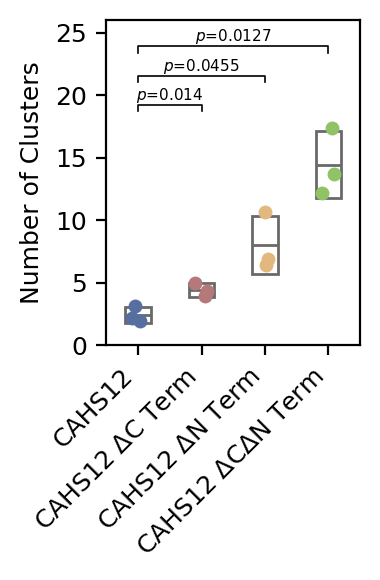

In [20]:
## number of clusters

import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
from scipy.stats import ttest_ind


xnames = ['CAHS12', r'CAHS12 $\Delta$C Term', r'CAHS12 $\Delta$N Term', 'CAHS12 $\Delta$C$\Delta$N Term']


data = [
    cluster_full,
    cluster_dc,
    cluster_dn,
    cluster_l
]

data = [np.asarray(g, dtype=float) for g in data]

max_val = max(np.max(g) for g in data)

group1, group2, group3, group4 = data

# Welch's t-test vs CAHS12
_, pval_c = ttest_ind(group1, group2, equal_var=False)
_, pval_n = ttest_ind(group1, group3, equal_var=False)
_, pval_l = ttest_ind(group1, group4, equal_var=False)

colors = ['#576fa0', '#b57979', '#e3b87f', '#90c266']
xpos = np.arange(1, 5)  # 1..4
size = 25

means = [np.mean(g) for g in data]
# Use sample SD by default (ddof=1); fall back to 0 if n=1
stds = [np.std(g, ddof=1) if len(g) > 1 else 0.0 for g in data]

# --- Plot ---
plt.figure(figsize=(2, 3), dpi=200)
ax = plt.gca()
box_width = 0.4

# Mean ± SD boxes
for x, mean, std, color in zip(xpos, means, stds, colors):
    rect = patches.Rectangle(
        (x - box_width / 2, mean - std),
        width=box_width,
        height=2 * std,
        edgecolor='dimgray',
        facecolor='white',
        linewidth=1.0,
        zorder=2
    )
    ax.add_patch(rect)

    # Mean line inside box
    ax.hlines(mean, x - box_width / 2, x + box_width / 2,
              color='dimgray', linewidth=1.0, zorder=3)

# Scatter points with reproducible jitter
rng = np.random.default_rng(0)
for i, (group, color) in enumerate(zip(data, colors)):
    jittered_x = np.full(len(group), xpos[i]) + rng.uniform(-0.1, 0.1, len(group))
    ax.scatter(jittered_x, group, facecolor=color, edgecolor=color,
               s=size, linewidth=0, zorder=4, alpha=1)

# Axes formatting
ax.set_xticks(xpos)
ax.set_xticklabels(xnames, fontsize=9, rotation=45, ha='right')
ax.set_ylabel(r'Number of Clusters', fontsize=9)
ax.tick_params(labelsize=9)
ax.set_xlim(0.5, 4.5)

ymin = 0.0
ymax = 26.0
ax.set_ylim(ymin, ymax)

pairs = [
    (xpos[0], xpos[1], pval_c),
    (xpos[0], xpos[2], pval_n),
    (xpos[0], xpos[3], pval_l),
]

yr = ymax - ymin
base = max_val + 0.05 * yr   # start a bit above highest datapoint
step = 0.09 * yr            # vertical spacing between brackets
h = 0.02 * yr               # bracket height

max_needed = base + (len(pairs) - 1) * step + h + 0.02 * yr
if max_needed > ymax:
    ax.set_ylim(ymin, max_needed)
    ymin, ymax = ax.get_ylim()
    yr = ymax - ymin
    base = max_val + 0.05 * yr
    step = 0.07 * yr
    h = 0.02 * yr

for k, (x1, x2, p) in enumerate(pairs):
    add_sig_bracket(ax, x1, x2, base + k * step, h, f'$p$={p:.3g}', fs=5.5, lw=0.6)

plt.tight_layout()
plt.savefig('num_cluster.pdf', format='pdf', dpi=400, transparent=True, bbox_inches='tight')
plt.show()


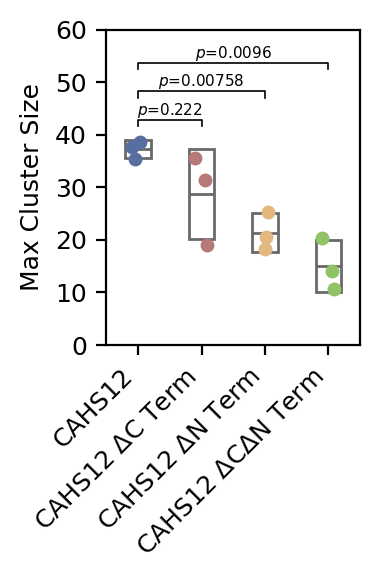

In [21]:
xnames = [
    'CAHS12',
    r'CAHS12 $\Delta$C Term',
    r'CAHS12 $\Delta$N Term',
    r'CAHS12 $\Delta$C$\Delta$N Term'
]

data = [
    size_full,
    size_dc,
    size_dn,
    size_l
]

# Ensure arrays
data = [np.asarray(g, dtype=float) for g in data]
max_val = max(np.max(g) for g in data)

group1, group2, group3, group4 = data

_, pval_c = ttest_ind(group1, group2, equal_var=False)
_, pval_n = ttest_ind(group1, group3, equal_var=False)
_, pval_l = ttest_ind(group1, group4, equal_var=False)

xpos = np.arange(1, 5)  # 1..4
size = 25

means = [np.mean(g) for g in data]
stds = [np.std(g, ddof=1) if len(g) > 1 else 0.0 for g in data]

plt.figure(figsize=(2, 3), dpi=200)
ax = plt.gca()
box_width = 0.4

for x, mean, std, color in zip(xpos, means, stds, colors):
    rect = patches.Rectangle(
        (x - box_width / 2, mean - std),
        width=box_width,
        height=2 * std,
        edgecolor='dimgray',
        facecolor='white',
        linewidth=1.0,
        zorder=2
    )
    ax.add_patch(rect)

    ax.hlines(mean, x - box_width / 2, x + box_width / 2,
              color='dimgray', linewidth=1.0, zorder=3)

rng = np.random.default_rng(0)
for i, (group, color) in enumerate(zip(data, colors)):
    jittered_x = np.full(len(group), xpos[i]) + rng.uniform(-0.1, 0.1, len(group))
    ax.scatter(jittered_x, group, facecolor=color, edgecolor=color,
               s=size, linewidth=0, zorder=4, alpha=1)

# Axes
ax.set_xticks(xpos)
ax.set_xticklabels(xnames, fontsize=9, rotation=45, ha='right')
ax.set_ylabel(r'Max Cluster Size', fontsize=9)
ax.tick_params(labelsize=9)
ax.set_xlim(0.5, 4.5)

ymin, ymax = 0.0, 60.0
ax.set_ylim(ymin, ymax)

pairs = [
    (xpos[0], xpos[1], pval_c),
    (xpos[0], xpos[2], pval_n),
    (xpos[0], xpos[3], pval_l),
]

yr = ymax - ymin
base = max_val + 0.05 * yr
step = 0.09 * yr
h = 0.02 * yr

max_needed = base + (len(pairs) - 1) * step + h + 0.02 * yr
if max_needed > ymax:
    ax.set_ylim(ymin, max_needed)

for k, (x1, x2, p) in enumerate(pairs):
    add_sig_bracket(ax, x1, x2, base + k * step, h, f'$p$={p:.3g}', fs=5.5, lw=0.6)

plt.tight_layout()
plt.savefig('max_cluster.pdf', format='pdf', dpi=400, transparent=True, bbox_inches='tight')
plt.show()

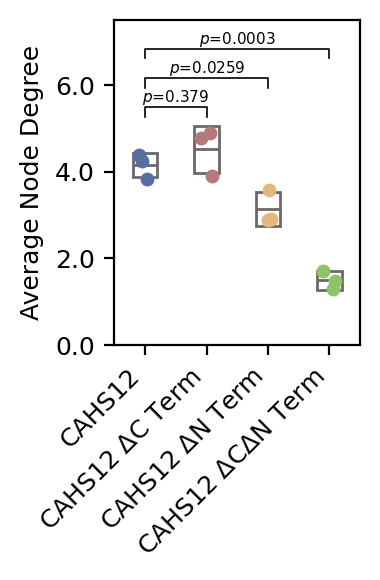

In [30]:
xnames = [
    'CAHS12',
    r'CAHS12 $\Delta$C Term',
    r'CAHS12 $\Delta$N Term',
    r'CAHS12 $\Delta$C$\Delta$N Term'
]

data = [
    degree_full,
    degree_dc,
    degree_dn,
    degree_l
]

data = [np.asarray(g, dtype=float) for g in data]
max_val = max(np.max(g) for g in data)

group1, group2, group3, group4 = data

_, pval_c = ttest_ind(group1, group2, equal_var=False)
_, pval_n = ttest_ind(group1, group3, equal_var=False)
_, pval_l = ttest_ind(group1, group4, equal_var=False)

xpos = np.arange(1, 5)  # 1..4
size = 25

means = [np.mean(g) for g in data]
stds = [np.std(g, ddof=1) if len(g) > 1 else 0.0 for g in data]

plt.figure(figsize=(2, 3), dpi=200)
ax = plt.gca()
box_width = 0.4

# Mean ± SD boxes
for x, mean, std, color in zip(xpos, means, stds, colors):
    rect = patches.Rectangle(
        (x - box_width / 2, mean - std),
        width=box_width,
        height=2 * std,
        edgecolor='dimgray',
        facecolor='white',
        linewidth=1.0,
        zorder=2
    )
    ax.add_patch(rect)

    ax.hlines(mean, x - box_width / 2, x + box_width / 2,
              color='dimgray', linewidth=1.0, zorder=3)

rng = np.random.default_rng(0)
for i, (group, color) in enumerate(zip(data, colors)):
    jittered_x = np.full(len(group), xpos[i]) + rng.uniform(-0.1, 0.1, len(group))
    ax.scatter(jittered_x, group, facecolor=color, edgecolor=color,
               s=size, linewidth=0, zorder=4, alpha=1)

ax.set_xticks(xpos)
ax.set_xticklabels(xnames, fontsize=9, rotation=45, ha='right')
ax.set_ylabel(r'Average Node Degree', fontsize=9)
ax.tick_params(labelsize=9)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.1f}'))
ax.set_xlim(0.5, 4.5)

# Keep your y-range, expand if needed for brackets
ymin, ymax = 0, 7.5
ax.set_ylim(ymin, ymax)

# Significance brackets (vs CAHS12)
pairs = [
    (xpos[0], xpos[1], pval_c),
    (xpos[0], xpos[2], pval_n),
    (xpos[0], xpos[3], pval_l),
]

yr = ymax - ymin
base = max_val + 0.05 * yr
step = 0.09 * yr   # a bit larger spacing since yr is small
h = 0.03 * yr

max_needed = base + (len(pairs) - 1) * step + h + 0.02 * yr
if max_needed > ymax:
    ax.set_ylim(ymin, max_needed)

for k, (x1, x2, p) in enumerate(pairs):
    add_sig_bracket(ax, x1, x2, base + k * step, h, f'$p$={p:.3g}', fs=5.5, lw=0.6)

plt.tight_layout()
plt.savefig('node_degree.pdf', format='pdf', dpi=400, transparent=True, bbox_inches='tight')
plt.show()